In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import load_breast_cancer

In [4]:
# Load the dataset
breast_cancer = load_breast_cancer()
X = breast_cancer.data
y = breast_cancer.target

# Create a DataFrame
data = pd.DataFrame(X, columns=breast_cancer.feature_names)
data['target'] = y

In [6]:
print(data.head())
print(data.info())
print(data.describe())

   mean radius  mean texture  mean perimeter  mean area  mean smoothness  \
0        17.99         10.38          122.80     1001.0          0.11840   
1        20.57         17.77          132.90     1326.0          0.08474   
2        19.69         21.25          130.00     1203.0          0.10960   
3        11.42         20.38           77.58      386.1          0.14250   
4        20.29         14.34          135.10     1297.0          0.10030   

   mean compactness  mean concavity  mean concave points  mean symmetry  \
0           0.27760          0.3001              0.14710         0.2419   
1           0.07864          0.0869              0.07017         0.1812   
2           0.15990          0.1974              0.12790         0.2069   
3           0.28390          0.2414              0.10520         0.2597   
4           0.13280          0.1980              0.10430         0.1809   

   mean fractal dimension  ...  worst texture  worst perimeter  worst area  \
0             

In [7]:
print(data.isnull().sum())
print(data.duplicated().sum())

mean radius                0
mean texture               0
mean perimeter             0
mean area                  0
mean smoothness            0
mean compactness           0
mean concavity             0
mean concave points        0
mean symmetry              0
mean fractal dimension     0
radius error               0
texture error              0
perimeter error            0
area error                 0
smoothness error           0
compactness error          0
concavity error            0
concave points error       0
symmetry error             0
fractal dimension error    0
worst radius               0
worst texture              0
worst perimeter            0
worst area                 0
worst smoothness           0
worst compactness          0
worst concavity            0
worst concave points       0
worst symmetry             0
worst fractal dimension    0
target                     0
dtype: int64
0


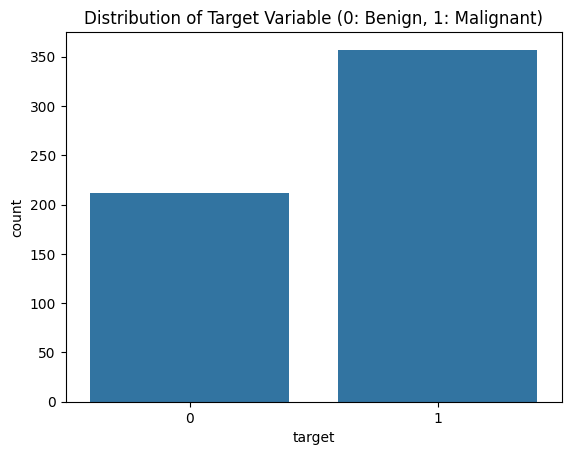

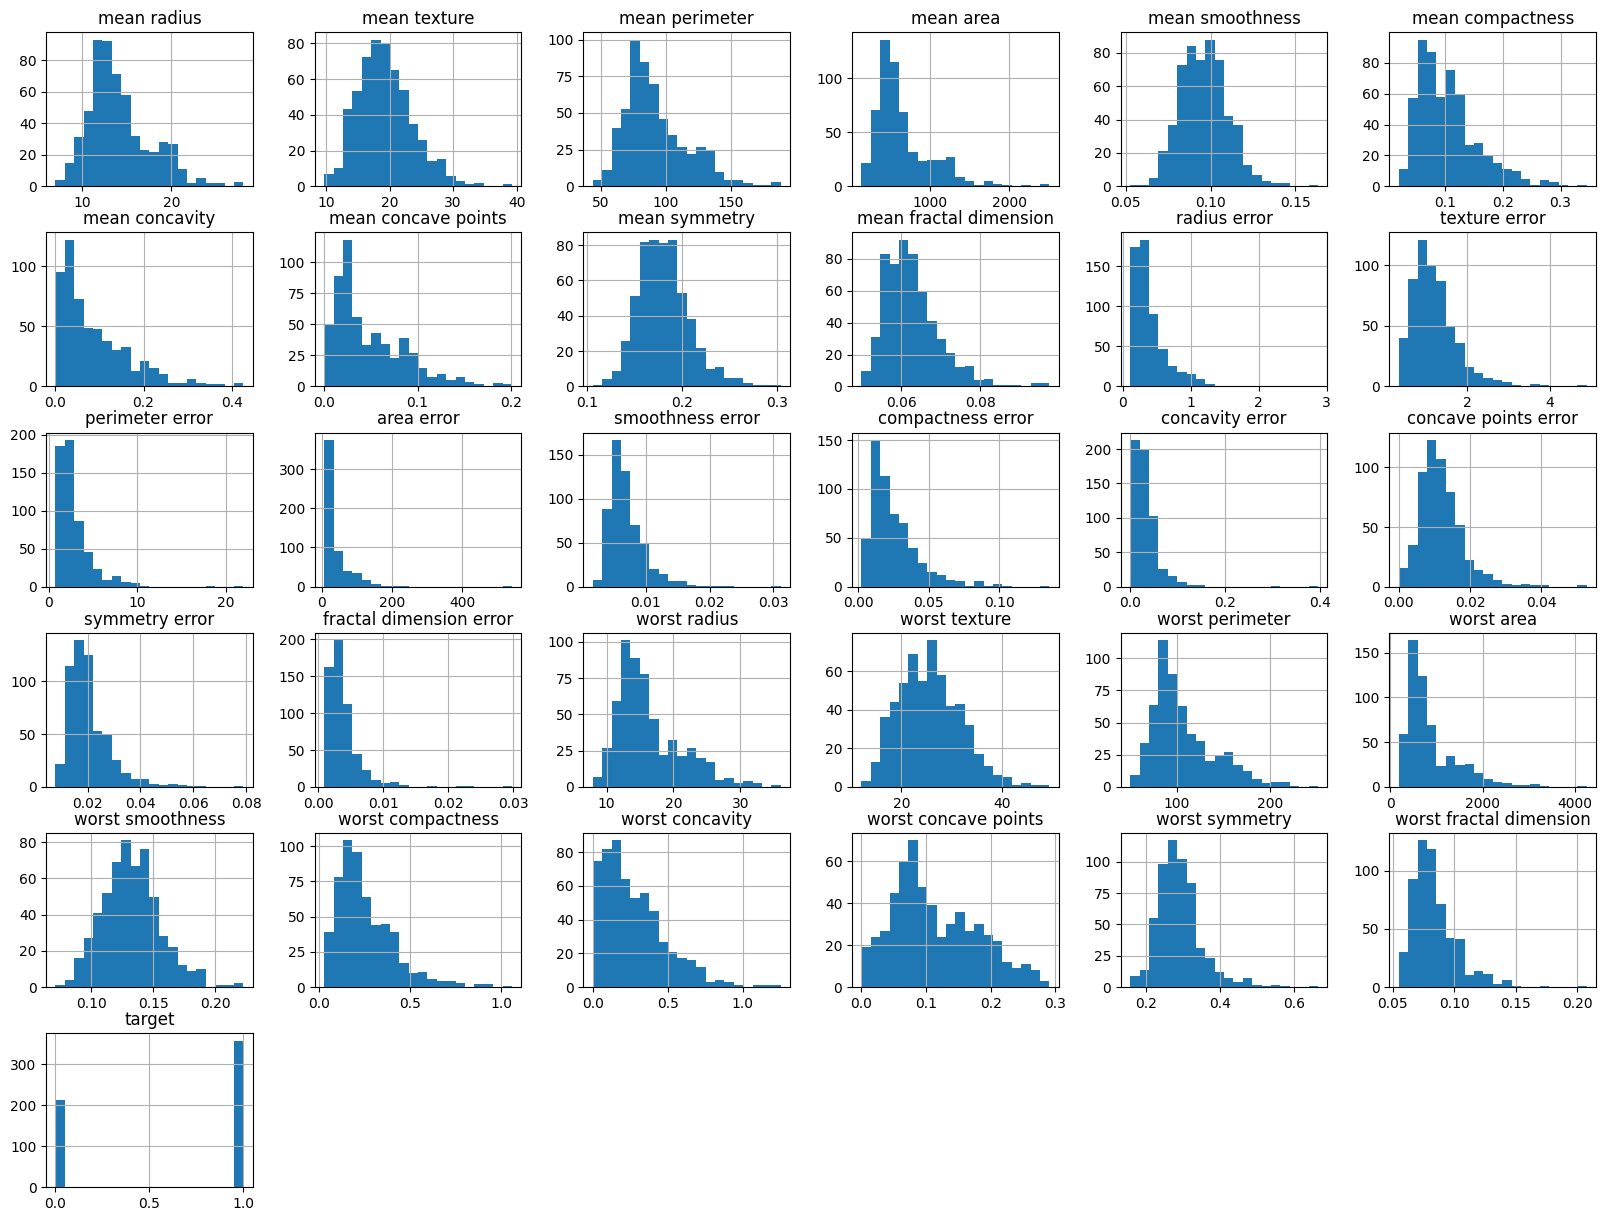

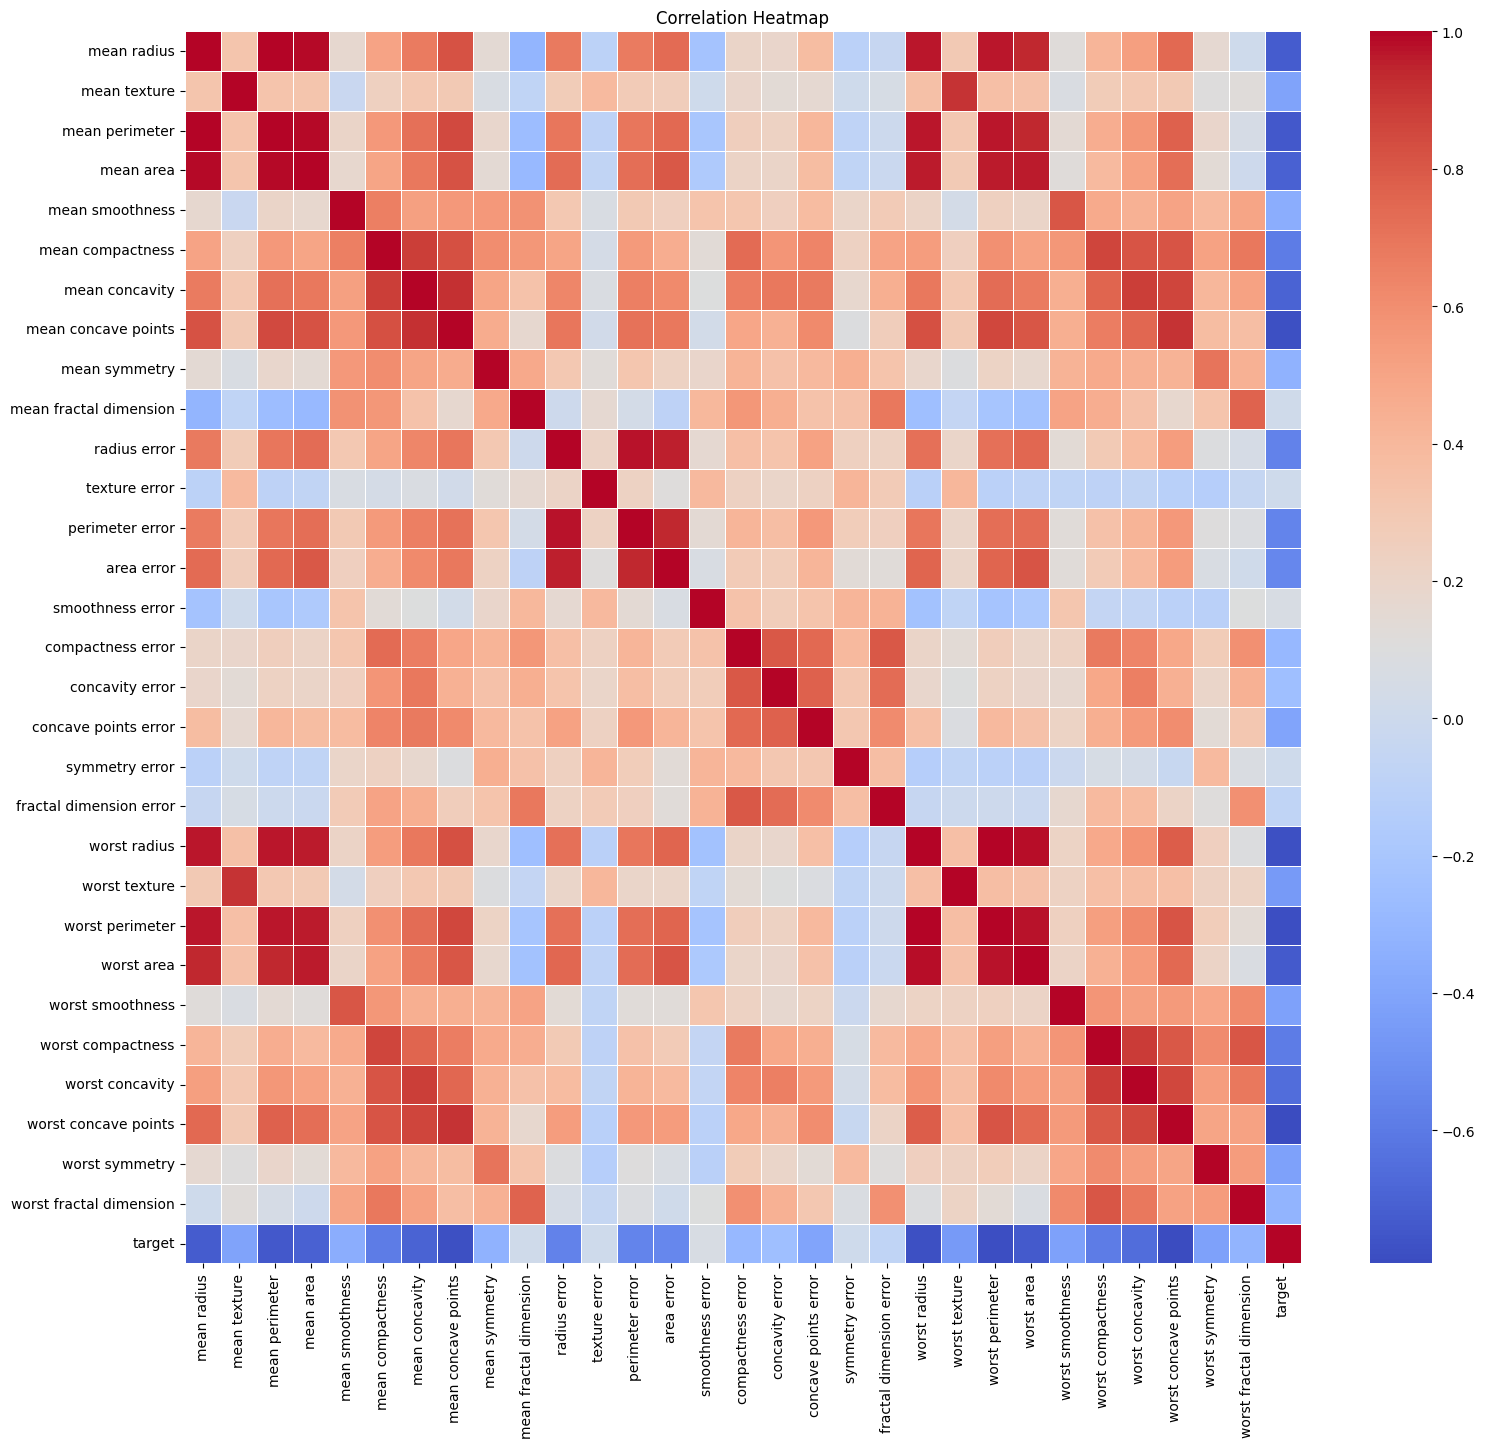

In [8]:
# Plot distribution of target variable
sns.countplot(x='target', data=data)
plt.title('Distribution of Target Variable (0: Benign, 1: Malignant)')
plt.show()

# Histogram for features
data.hist(bins=20, figsize=(20, 15))
plt.show()

# Correlation Heatmap
plt.figure(figsize=(18, 16))
corr = data.corr()
sns.heatmap(corr, annot=False, cmap='coolwarm', linewidths=0.5)
plt.title('Correlation Heatmap')
plt.show()

In [9]:
# Identify features with strong correlation to target
cor_target = abs(corr["target"])
relevant_features = cor_target[cor_target > 0.5]
print(relevant_features)

mean radius             0.730029
mean perimeter          0.742636
mean area               0.708984
mean compactness        0.596534
mean concavity          0.696360
mean concave points     0.776614
radius error            0.567134
perimeter error         0.556141
area error              0.548236
worst radius            0.776454
worst perimeter         0.782914
worst area              0.733825
worst compactness       0.590998
worst concavity         0.659610
worst concave points    0.793566
target                  1.000000
Name: target, dtype: float64


### Dimensionality Reduction
We could consider techniques like Principal Component Analysis (PCA) to reduce the feature space.

In [10]:
from sklearn.decomposition import PCA

pca = PCA(n_components=10)
X_pca = pca.fit_transform(X)

### Data Splitting:
We split the data into training and testing sets.

In [11]:
from sklearn.model_selection import train_test_split

# Using a subset of features based on correlation (Optional)
selected_features = ['mean radius', 'mean texture', 'mean perimeter', 'mean area', 'mean smoothness',
                     'mean compactness', 'mean concavity', 'mean concave points', 'mean symmetry', 'mean fractal dimension']

X_train, X_test, y_train, y_test = train_test_split(data[selected_features], data['target'], test_size=0.2, random_state=42)

Logistic Regression


In [12]:
from sklearn.linear_model import LogisticRegression

lr_model = LogisticRegression(solver='liblinear', random_state=42)
lr_model.fit(X_train, y_train)

LogisticRegression(random_state=42, solver='liblinear')

Support Vector Machine (SVC)

In [13]:
from sklearn.svm import SVC

svc_model = SVC(kernel='linear', random_state=42)
svc_model.fit(X_train, y_train)

SVC(kernel='linear', random_state=42)

Random Forest Classifier

In [14]:
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)

RandomForestClassifier(random_state=42)

Gradient Boosting Classifier

In [15]:
from sklearn.ensemble import GradientBoostingClassifier

gbc_model = GradientBoostingClassifier(n_estimators=100, random_state=42)
gbc_model.fit(X_train, y_train)

GradientBoostingClassifier(random_state=42)

### Model Evaluation

Evaluate each model using appropriate metrics, such as accuracy, precision, recall, and F1-score.

In [16]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix

models = {
    "Logistic Regression": lr_model,
    "SVC": svc_model,
    "Random Forest": rf_model,
    "Gradient Boosting": gbc_model
}

for model_name, model in models.items():
    y_pred = model.predict(X_test)
    print(f"Model: {model_name}")
    print(f"Accuracy: {accuracy_score(y_test, y_pred):.4f}")
    print(f"Precision: {precision_score(y_test, y_pred):.4f}")
    print(f"Recall: {recall_score(y_test, y_pred):.4f}")
    print(f"F1 Score: {f1_score(y_test, y_pred):.4f}")
    print("Confusion Matrix:")
    print(confusion_matrix(y_test, y_pred))
    print("-----------")

Model: Logistic Regression
Accuracy: 0.9386
Precision: 0.9444
Recall: 0.9577
F1 Score: 0.9510
Confusion Matrix:
[[39  4]
 [ 3 68]]
-----------
Model: SVC
Accuracy: 0.9386
Precision: 0.9571
Recall: 0.9437
F1 Score: 0.9504
Confusion Matrix:
[[40  3]
 [ 4 67]]
-----------
Model: Random Forest
Accuracy: 0.9474
Precision: 0.9577
Recall: 0.9577
F1 Score: 0.9577
Confusion Matrix:
[[40  3]
 [ 3 68]]
-----------
Model: Gradient Boosting
Accuracy: 0.9561
Precision: 0.9583
Recall: 0.9718
F1 Score: 0.9650
Confusion Matrix:
[[40  3]
 [ 2 69]]
-----------


In [17]:
from sklearn.model_selection import GridSearchCV

# Example of hyperparameter tuning for Random Forest
param_grid = {
    'n_estimators': [50, 100, 200],
    'max_depth': [4, 6, 8, 10]
}

rf_tuned_model = GridSearchCV(RandomForestClassifier(random_state=42), param_grid, cv=5)
rf_tuned_model.fit(X_train, y_train)

print("Best parameters for Random Forest:", rf_tuned_model.best_params_)
print("Best score for Random Forest:", rf_tuned_model.best_score_)

Best parameters for Random Forest: {'max_depth': 8, 'n_estimators': 200}
Best score for Random Forest: 0.9362637362637363


### Model Deployment

For model deployment, we can use a simple web framework such as Flask or Streamlit. We’ll demonstrate how to deploy using Flask:

Deploying with Flask:

	-	Save the trained model using pickle.
	-	Create a Flask application that loads the model and provides an endpoint for predictions.
	-	Serve the Flask app.


In [18]:
import pickle

best_model = rf_tuned_model.best_estimator_  # or the best performing model from earlier
with open('breast_cancer_model.pkl', 'wb') as file:
    pickle.dump(best_model, file)

In [20]:
from flask import Flask, request, jsonify
import pickle
import numpy as np

app = Flask(__name__)

# Load the trained model
model = pickle.load(open('breast_cancer_model.pkl', 'rb'))

@app.route('/predict', methods=['POST'])
def predict():
    data = request.get_json()
    # Convert the data into a numpy array or appropriate format
    input_data = np.array([data['mean radius'], data['mean texture'], data['mean perimeter'],
                           data['mean area'], data['mean smoothness'], data['mean compactness'],
                           data['mean concavity'], data['mean concave points'], data['mean symmetry'],
                           data['mean fractal dimension']]).reshape(1, -1)
    prediction = model.predict(input_data)
    return jsonify({"prediction": int(prediction[0])})

if __name__ == '__main__':
    app.run(debug=True)

 * Serving Flask app '__main__'
 * Debug mode: on


 * Running on http://127.0.0.1:5000
Press CTRL+C to quit
 * Restarting with stat
Traceback (most recent call last):
  File "<frozen runpy>", line 198, in _run_module_as_main
  File "<frozen runpy>", line 88, in _run_code
  File "/Users/virensasalu/Library/Python/3.12/lib/python/site-packages/ipykernel_launcher.py", line 18, in <module>
    app.launch_new_instance()
  File "/Users/virensasalu/Library/Python/3.12/lib/python/site-packages/traitlets/config/application.py", line 1074, in launch_instance
    app.initialize(argv)
  File "/Users/virensasalu/Library/Python/3.12/lib/python/site-packages/traitlets/config/application.py", line 118, in inner
    return method(app, *args, **kwargs)
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/Users/virensasalu/Library/Python/3.12/lib/python/site-packages/ipykernel/kernelapp.py", line 692, in initialize
    self.init_sockets()
  File "/Users/virensasalu/Library/Python/3.12/lib/python/site-packages/ipykernel/kernelapp.py", line 331, in init_socket

SystemExit: 1

/Users/virensasalu/Library/Python/3.12/lib/python/site-packages/IPython/core/interactiveshell.py:3585: UserWarning: To exit: use 'exit', 'quit', or Ctrl-D.
  warn("To exit: use 'exit', 'quit', or Ctrl-D.", stacklevel=1)
